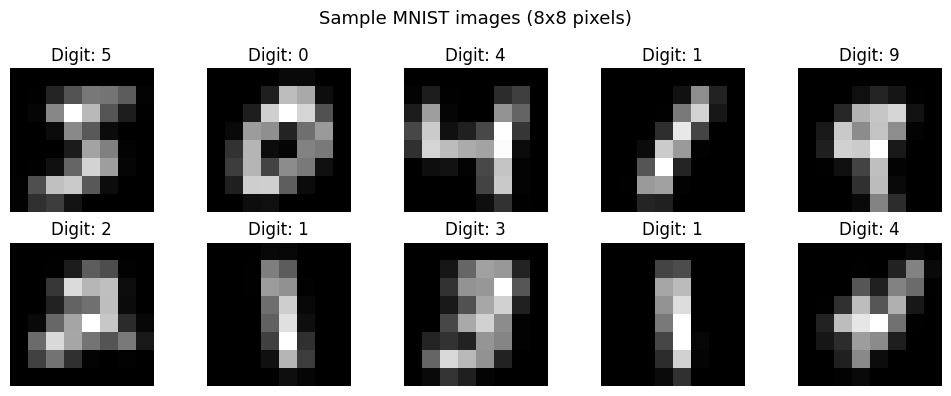

Each image shape: torch.Size([1, 8, 8])
Pixel values range: 0.0 to 1.0
Total images: 60000


In [3]:
# Cell 1: Imports & Data Loading
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import datasets, transforms

# Download MNIST and resize images to 8x8
transform = transforms.Compose([
    transforms.Resize((8, 8)),
    transforms.ToTensor()
])

dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Let's just look at what we're working with
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img, label = dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Digit: {label}')
    ax.axis('off')
plt.suptitle('Sample MNIST images (8x8 pixels)', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Each image shape: {dataset[0][0].shape}")
print(f"Pixel values range: 0.0 to 1.0")
print(f"Total images: {len(dataset)}")

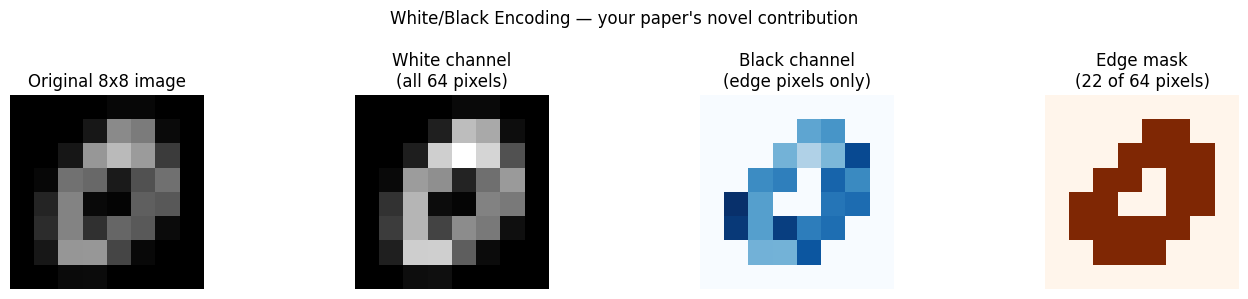

Amplitude vector length: 2048 (2^11 = 2048)
Edge pixels dual-encoded: 22
Why it matters: preserves contrast that standard normalization destroys


In [4]:
# Cell 2: White/Black Amplitude Encoding
# This is the novel contribution from your paper

def white_black_encode(image_tensor):
    """
    Encode an 8x8 image into a 2048-length amplitude vector.
    
    Problem with standard encoding: L2 normalization destroys brightness contrast.
    Two images with same pattern but different brightness become identical quantum states.
    
    Our fix: encode edge pixels TWICE — once as brightness, once as darkness.
    This preserves the log-odds ratio of each pixel, saving contrast information.
    """
    pixels = image_tensor.squeeze().numpy().flatten() * 16  # scale to [0, 16]
    
    alpha = np.zeros(2048)
    
    for i, p in enumerate(pixels):
        # WHITE CHANNEL (indices 0-63): every pixel, by brightness
        alpha[i] = p / 16.0
        
        # BLACK CHANNEL (indices 64-127): only edge pixels (not pure black or white)
        if 2 <= p <= 14:
            alpha[i + 64] = 1 - (p / 16.0)  # complementary intensity
    
    # Normalize so amplitudes are a valid quantum state
    norm = np.linalg.norm(alpha)
    if norm > 0:
        alpha = alpha / norm
    
    return alpha

# --- Visualize on a digit 0 ---
for img, label in dataset:
    if label == 0:
        sample = img
        break

pixels_raw = sample.squeeze().numpy() * 16
alpha = white_black_encode(sample)
edge_mask = (pixels_raw >= 2) & (pixels_raw <= 14)

fig, axes = plt.subplots(1, 4, figsize=(14, 3))

axes[0].imshow(pixels_raw, cmap='gray', vmin=0, vmax=16)
axes[0].set_title('Original 8x8 image')

axes[1].imshow(alpha[:64].reshape(8, 8), cmap='gray')
axes[1].set_title('White channel\n(all 64 pixels)')

black_vis = np.zeros((8, 8))
black_vis[edge_mask] = alpha[64:128].reshape(8, 8)[edge_mask]
axes[2].imshow(black_vis, cmap='Blues')
axes[2].set_title('Black channel\n(edge pixels only)')

axes[3].imshow(edge_mask, cmap='Oranges')
axes[3].set_title(f'Edge mask\n({edge_mask.sum()} of 64 pixels)')

for ax in axes:
    ax.axis('off')

plt.suptitle("White/Black Encoding — your paper's novel contribution", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Amplitude vector length: {len(alpha)} (2^11 = 2048)")
print(f"Edge pixels dual-encoded: {edge_mask.sum()}")
print(f"Why it matters: preserves contrast that standard normalization destroys")

In [6]:
# Cell 3: Build the 11-Qubit Quantum Circuit
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import RealAmplitudes

# --- Step 1: The input encoding circuit ---
# We have 2048 amplitude values but only need 11 rotation angles
# So we use a linear projection: 2048 -> 11 angles
# (6 angles for white channel qubits 0-5, 5 for black channel qubits 6-10)

def encode_to_angles(alpha):
    """Project 2048-length amplitude vector down to 11 rotation angles."""
    white = alpha[:64]   # white channel pixels
    black = alpha[64:128]  # black channel pixels
    
    # Simple linear projection: split each channel into groups, take mean
    white_angles = np.array([white[i*10:(i+1)*10].mean() for i in range(6)]) * np.pi
    black_angles = np.array([black[i*12:(i+1)*12].mean() for i in range(5)]) * np.pi
    
    return np.concatenate([white_angles, black_angles])  # 11 angles total

# --- Step 2: Build the parameterized quantum circuit ---
n_qubits = 11

# RealAmplitudes ansatz: applies RY rotations + entangling CNOT gates
# reps=1 means one layer of this pattern (depth 22, gives us 22 trainable weights)
ansatz = RealAmplitudes(n_qubits, reps=1, entanglement='full')

print(f"Ansatz parameters: {ansatz.num_parameters}")
print(f"Circuit depth: {ansatz.decompose().depth()}")

# --- Step 3: Visualize the circuit ---
# Show just a 4-qubit version so it fits on screen (same structure, just smaller)
small_demo = RealAmplitudes(4, reps=1, entanglement='full')
print("\n4-qubit demo circuit (same structure as our 11-qubit circuit):")
print(small_demo.decompose())

# --- Step 4: Show what one encoded sample looks like ---
sample_alpha = white_black_encode(sample)  # reuse digit 0 from Cell 2
sample_angles = encode_to_angles(sample_alpha)

print(f"\nEncoding pipeline for one image:")
print(f"  8x8 pixels (64 values)")
print(f"  → amplitude vector (2048 values)")  
print(f"  → 11 rotation angles: {np.round(sample_angles, 3)}")
print(f"\nThese 11 angles become the RY gate rotations on qubits 0-10")
print(f"Then the ansatz's 22 trainable weights adjust during training")
print(f"Total trainable parameters: 22 (quantum) + 2 (classical output) = 24")

C:\Users\13213\AppData\Local\Temp\ipykernel_17808\774107069.py:27: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(n_qubits, reps=1, entanglement='full')
C:\Users\13213\AppData\Local\Temp\ipykernel_17808\774107069.py:34: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  small_demo = RealAmplitudes(4, reps=1, entanglement='full')


Ansatz parameters: 22
Circuit depth: 21

4-qubit demo circuit (same structure as our 11-qubit circuit):
     ┌──────────┐                    ┌──────────┐                        
q_0: ┤ Ry(θ[0]) ├──■────■─────────■──┤ Ry(θ[4]) ├────────────────────────
     ├──────────┤┌─┴─┐  │         │  └──────────┘┌──────────┐            
q_1: ┤ Ry(θ[1]) ├┤ X ├──┼────■────┼───────■──────┤ Ry(θ[5]) ├────────────
     ├──────────┤└───┘┌─┴─┐┌─┴─┐  │       │      └──────────┘┌──────────┐
q_2: ┤ Ry(θ[2]) ├─────┤ X ├┤ X ├──┼───────┼───────────■──────┤ Ry(θ[6]) ├
     ├──────────┤     └───┘└───┘┌─┴─┐   ┌─┴─┐       ┌─┴─┐    ├──────────┤
q_3: ┤ Ry(θ[3]) ├───────────────┤ X ├───┤ X ├───────┤ X ├────┤ Ry(θ[7]) ├
     └──────────┘               └───┘   └───┘       └───┘    └──────────┘

Encoding pipeline for one image:
  8x8 pixels (64 values)
  → amplitude vector (2048 values)
  → 11 rotation angles: [0.005 0.164 0.256 0.167 0.158 0.14  0.    0.21  0.277 0.346 0.115]

These 11 angles become the RY gate rotation